<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Navier_Stokes_gamlastan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Navier-Stokes equations**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Navier-Stokes equations, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [45]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden.

# Copyright (C) 2020 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [46]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Navier-Stokes equations take the form

$\dot u + (u\cdot \nabla)u + \nabla p -\Delta u = f,\quad \nabla \cdot u=0,$

together with suitable initial and boundary conditions.

Here we present a FEniCS implementation of a stabilized space-time finite element method to solve the Navier-Stokes equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

We seek a finite element approximation $(u,p)\in V\times Q$ such that

$(\dot u + (u\cdot \nabla)u, v) - (p,\nabla \cdot v) + (\nu \nabla u,\nabla v) + (\nabla \cdot u, q) + SD(u,p;v,q) = (f,v),$

for all test functions $(v,q) \in \hat V\times \hat Q$, where $SD(u,p;v,q)$ is a residual based stabilization term.

We present an example of flow past a circular cylinder, for which we compute the force on the surface of the cylinder $\Gamma$ in the direction $\phi$, by Green's formula:

$
F(u,p,\phi)= ~<\nu \nabla u\cdot n-pn, \Phi>_{\Gamma} ~=~(\dot u+(u\cdot \nabla)u, \Phi) + (\nu \nabla u,\nabla \Phi) - (p,\nabla \cdot\Phi)-(f,\Phi),
$

with $\Phi\in V$ a fuinction for which $\Phi\vert _{\Gamma}=\phi$ and $\Phi\vert_{\partial \Omega \setminus \Gamma}=0$. With $\phi=(1,0)$ we get the drag force $F_D$, and with $\phi=(0,1)$ the lift force $F_L$. The drag and lift coefficients are obtained by normalization,

$
c_D = \frac{2F_D}{\rho U^2D}, \quad c_L = \frac{2F_L}{\rho U^2D}
$

where $\rho$ is the density (here $\rho=1$), $U$ the characteristic velocity (here $U=1$), and $D$ the characteristic length scale (here $D$ is the diameter of the cylinder).

The Reynolds number is defined as $Re=\frac{UD}{\nu}$

To read more about how to use similar methods for more complex problems, see e.g.

[Hoffman, Johan, et al. "Towards a parameter-free method for high reynolds number turbulent flow simulation based on adaptive finite element approximation." Computer Methods in Applied Mechanics and Engineering 288 (2015): 60-74.](https://www.sciencedirect.com/science/article/pii/S0045782514004836)


# **Method**

**Define domain and mesh**

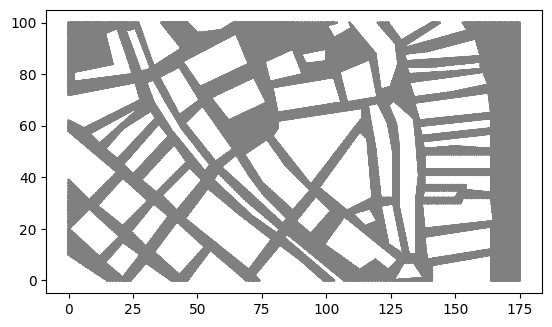

In [47]:
# Define rectangular domain
L = 175
H = 100

# Define circle
xc = 1.0
yc = 0.5*H
rc = 0.2

# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

# Gamla stan
hus1 = Polygon([Point(141, 100), Point(124, 100), Point(129, 93)])
hus2 = Polygon([Point(153, 100), Point(144, 100), Point(130, 91), Point(130, 90), Point(155, 97)])
hus3 = Polygon([Point(158, 94), Point(139, 89), Point(130, 88), Point(131, 85), Point(160, 87)])
hus4 = Polygon([Point(160, 85), Point(141, 83), Point(131, 83), Point(132, 80), Point(148, 81), Point(160, 82)])
hus5 = Polygon([Point(161, 81), Point(147, 79), Point(132, 77), Point(134, 71), Point(149, 73), Point(163, 76)])
hus6 = Polygon([Point(163, 73), Point(134, 69), Point(136, 62), Point(164, 65)])
hus7 = Polygon([Point(164, 63), Point(136, 60), Point(137, 56), Point(164, 59)])
hus8 = Polygon([Point(164, 57), Point(137, 54), Point(138, 51), Point(150, 52), Point(164, 51)])
hus9 = Polygon([Point(164, 49), Point(138, 49), Point(138, 43), Point(164, 43)])
hus10 = Polygon([Point(164, 41), Point(138, 41), Point(138, 37), Point(154, 37), Point(154, 35), Point(164, 34)])
hus11 = Polygon([Point(152, 35), Point(138, 35), Point(137, 32), Point(150, 32)])
hus12 = Polygon([Point(164, 32), Point(153, 32), Point(152, 30), Point(137, 30), Point(138, 20), Point(165, 23)])
hus13 = Polygon([Point(164, 21), Point(138, 17), Point(139, 8), Point(164, 12)])
hus14 = Polygon([Point(164, 10), Point(141, 6), Point(141, 0), Point(164, 0)])
hus15 = Polygon([Point(120, 100), Point(109, 100), Point(119, 88), Point(121, 74), Point(125, 75), Point(128, 84), Point(127, 92)])
hus16 = Polygon([Point(126, 70), Point(124, 68), Point(127, 61), Point(128, 53), Point(128, 41), Point(128, 29), Point(132, 10), Point(135, 10), Point(135, 32), Point(136, 41), Point(135, 54), Point(134, 63)])
hus17 = Polygon([Point(120, 69), Point(116, 68), Point(119, 51), Point(121, 32), Point(126, 32), Point(126, 50), Point(124, 61)])
hus18 = Polygon([Point(126, 30), Point(121, 29), Point(124, 14), Point(130, 10)])
hus19 = Polygon([Point(116, 55), Point(113, 58), Point(97, 36), Point(108, 27), Point(118, 32), Point(116, 55)])
hus20 = Polygon([Point(117, 28), Point(110, 26), Point(115, 21), Point(120, 23)])
hus21 = Polygon([Point(114, 67), Point(81, 62), Point(81, 59), Point(79, 56), Point(94, 37), Point(114, 63)])
hus22 = Polygon([Point(117, 86), Point(105, 81), Point(108, 69), Point(120, 71)])
hus23 = Polygon([Point(103, 79), Point(79, 75), Point(81, 65), Point(106, 69)])
hus24 = Polygon([Point(100, 90), Point(90, 88), Point(92, 84), Point(100, 85)])
hus25 = Polygon([Point(87, 90), Point(76, 85), Point(78, 77), Point(91, 80)])
hus26 = Polygon([Point(104, 100), Point(100, 99), Point(103, 94), Point(110, 98), Point(109, 100)])
hus27 = Polygon([Point(65, 96), Point(44, 85), Point(51, 75), Point(70, 84)])
hus28 = Polygon([Point(72, 79), Point(55, 71), Point(62, 62), Point(77, 69)])
hus29 = Polygon([Point(77, 55), Point(68, 49), Point(75, 38), Point(87, 27), Point(94, 35), Point(84, 45)])
hus30 = Polygon([Point(96, 33), Point(88, 23), Point(94, 18), Point(102, 27)])
hus31 = Polygon([Point(107, 25), Point(99, 14), Point(113, 4), Point(119, 8), Point(124, 4), Point(128, 8)])
hus32 = Polygon([Point(134, 7), Point(130, 7), Point(126, 0), Point(138, 1)])
hus33 = Polygon([Point(64, 100), Point(46, 100), Point(50, 96), Point(59, 97)])
hus34 = Polygon([Point(36, 100), Point(27, 100), Point(33, 83), Point(44, 90)])
hus35 = Polygon([Point(43, 83), Point(35, 79), Point(43, 64), Point(51, 70)])
hus36 = Polygon([Point(52, 68), Point(45, 61), Point(57, 46), Point(64, 51)])
hus37 = Polygon([Point(65, 49), Point(59, 44), Point(69, 35), Point(83, 22), Point(85, 24), Point(76, 33), Point(70, 41)])
hus38 = Polygon([Point(26, 98), Point(22, 97), Point(28, 81), Point(32, 82)])
hus39 = Polygon([Point(33, 78), Point(30, 77), Point(33, 69), Point(40, 58), Point(53, 42), Point(55, 45), Point(44, 59), Point(38, 69)])
hus40 = Polygon([Point(58, 42), Point(56, 39), Point(71, 25), Point(81, 18), Point(82, 20), Point(69, 31)])
hus41 = Polygon([Point(85, 18), Point(83, 17), Point(103, 0), Point(107, 0)])
hus42 = Polygon([Point(19, 98), Point(14, 96), Point(17, 84), Point(2, 81), Point(2, 77), Point(25, 80)])
hus43 = Polygon([Point(26, 77), Point(0, 72), Point(0, 62), Point(6, 59), Point(28, 70)])
hus44 = Polygon([Point(30, 69), Point(8, 57), Point(12, 53)])
hus45 = Polygon([Point(32, 66), Point(21, 59), Point(14, 51), Point(19, 47), Point(34, 63)])
hus46 = Polygon([Point(35, 61), Point(21, 45), Point(25, 41), Point(39, 56)])
hus47 = Polygon([Point(41, 53), Point(28, 39), Point(34, 34), Point(46, 46)])
hus48 = Polygon([Point(47, 44), Point(36, 33), Point(42, 27), Point(52, 39)])
hus49 = Polygon([Point(54, 36), Point(45, 24), Point(70, 4), Point(79, 16), Point(66, 26)])
hus50 = Polygon([Point(82, 14), Point(72, 2), Point(74, 0), Point(99, 0), Point(90, 8)])
hus51 = Polygon([Point(0, 58), Point(0, 39), Point(8, 31), Point(19, 42)])
hus52 = Polygon([Point(21, 40), Point(11, 29), Point(21, 21), Point(31, 31)])
hus53 = Polygon([Point(33, 30), Point(24, 19), Point(30, 13), Point(39, 25)])
hus54 = Polygon([Point(42, 23), Point(33, 11), Point(43, 2), Point(53, 13)])
hus55 = Polygon([Point(55, 12), Point(46, 0), Point(69, 0)])
hus56 = Polygon([Point(8, 28), Point(0, 20), Point(12, 9), Point(20, 17)])
hus57 = Polygon([Point(21, 15), Point(14, 7), Point(21, 1), Point(28, 10)])
hus58 = Polygon([Point(30, 7), Point(24, 0), Point(40, 0)])
hus59 = Polygon([Point(0, 0), Point(15, 0), Point(0, 10)])
hus = hus1 + hus2 + hus3 + hus4 + hus5 + hus6 + hus7 + hus8 + hus9 + hus10 + hus11 + hus12 + hus13 + hus14 + hus15 + hus16 + hus17 + hus18 + hus19 + hus20 + hus21 + hus22 + hus23 + hus24 + hus25 + hus26 + hus27 + hus28 + hus29 + hus30 + hus31 + hus32 + hus33 + hus34 + hus35 + hus36 + hus37 + hus38 + hus39 + hus40 + hus41 + hus42 + hus43 + hus44 + hus45 + hus46 + hus47 + hus48 + hus49 + hus50 + hus51 + hus52 + hus53 + hus54 + hus55 + hus56 + hus57 + hus58 + hus59

resolution = 150
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - hus, resolution)


# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plt.figure()
plot(mesh)
plt.show()

**Define finite element approximation spaces**

In [48]:
# Generate finite element spaces (for velocity and pressure)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

# Pollution concentration space
C = FunctionSpace(mesh, "Lagrange", 1)

c = TrialFunction(C)
w = TestFunction(C)

c0 = Function(C)   # concentration at previous time step
c1 = Function(C)   # concentration at current time step

**Define boundary conditions**

In [49]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

# Examples of time dependent and stationary inflow conditions
#uin = Expression('4.0*x[1]*(1-x[1])', element = V.sub(0).ufl_element())
#uin = Expression('1.0 + 1.0*fabs(sin(t))', element = V.sub(0).ufl_element(), t=0.0)
uin = -1.0
bcu_in0 = DirichletBC(V.sub(0), uin, dbc_right)
bcu_in1 = DirichletBC(V.sub(1), 0.0, dbc_right)
bcu_upp0 = DirichletBC(V.sub(0), 0.0, dbc_upper)
bcu_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcu_low0 = DirichletBC(V.sub(0), 0.0, dbc_lower)
bcu_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)
bcu_obj0 = DirichletBC(V.sub(0), 0.0, dbc_objects)
bcu_obj1 = DirichletBC(V.sub(1), 0.0, dbc_objects)

pin = Expression('5.0*fabs(sin(t))', element = Q.ufl_element(), t=0.0)
pout = 0.0
bcp0 = DirichletBC(Q, pin, dbc_left)
#bcp1 = DirichletBC(Q, pout, dbc_right)

bcu = [bcu_in0, bcu_in1, bcu_upp0, bcu_upp1, bcu_low0, bcu_low1, bcu_obj0, bcu_obj1]
#bcu = [bcu_in0, bcu_in1, bcu_upp1, bcu_low1, bcu_obj0, bcu_obj1]
bcp = [bcp0]

# Pullutant boundary
bc_c_in = DirichletBC(C, Constant(0.0), dbc_right)
bc_c = [bc_c_in]

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# **Results**

**Define flow parameters**

In [50]:
# Set viscosity
nu = 5.4015e-7
#nu = 3.2385e-7

# Pollutant diffusion coefficient
Dpoll = Constant(0.5)

# Optional decay/removal rate, e.g. chemical decay or deposition
decay = Constant(0.0)

# Source of pollution
source_strength = 10.0
source_sigma = 2.0

S = Expression(
    "A*exp(-((x[0]-x1)*(x[0]-x1) + (x[1]-y1)*(x[1]-y1))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x2)*(x[0]-x2) + (x[1]-y2)*(x[1]-y2))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x3)*(x[0]-x3) + (x[1]-y3)*(x[1]-y3))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x4)*(x[0]-x4) + (x[1]-y4)*(x[1]-y4))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x5)*(x[0]-x5) + (x[1]-y5)*(x[1]-y5))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x6)*(x[0]-x6) + (x[1]-y6)*(x[1]-y6))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x7)*(x[0]-x7) + (x[1]-y7)*(x[1]-y7))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x8)*(x[0]-x8) + (x[1]-y8)*(x[1]-y8))/(2*sigma*sigma))"
    " + A*exp(-((x[0]-x9)*(x[0]-x9) + (x[1]-y9)*(x[1]-y9))/(2*sigma*sigma))",
    degree=2,
    A=10.0,
    x1=170.0, y1=10.0,
    x2=170.0,  y2=20.0,
    x3=170.0, y3=30.0,
    x4=170.0,  y4=40.0,
    x5=170.0,  y5=50.0,
    x6=170.0,  y6=60.0,
    x7=170.0,  y7=70.0,
    x8=170.0,  y8=80.0,
    x9=170.0,  y9=90.0,
    sigma=2.0
)

**Define method parameters**

In [51]:
# Define iteration functions
# (u0,p0) solution from previous time step
# (u1,p1) linearized solution at present time step
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)

# Set parameters for nonlinear and lienar solvers
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

**Define variational problem**

In [52]:
# Define variational problem

# Stabilization parameters
h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
d2 = h*u_mag

# Mean velocities for trapozoidal time stepping
um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)

# Momentum variational equation on residual form
Fu = inner((u - u0)/dt + grad(um)*um1, v)*dx - p1*div(v)*dx + nu*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*um1 + grad(p1), grad(v)*um1)*dx + d2*div(um)*div(v)*dx
au = lhs(Fu)
Lu = rhs(Fu)

# Continuity variational equation on residual form
Fp = d1*inner((u1 - u0)/dt + grad(um1)*um1 + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

# Mean concentration for trapezoidal / Crank-Nicolson time stepping
cm = 0.5*(c + c0)

# Pollution advection-diffusion-reaction equation
Fc = (
    ((c - c0)/dt)*w*dx
    + dot(u1, grad(cm))*w*dx
    + Dpoll*dot(grad(cm), grad(w))*dx
    + decay*cm*w*dx
    - S*w*dx
)

ac = lhs(Fc)
Lc = rhs(Fc)



**Triple decomposition**

**Compute force on boundary**

**Set plotting variables and open export files**

In [53]:
# Open files to export solution to Paraview
file_u = File("results-NS/u.pvd")
file_p = File("results-NS/p.pvd")
file_c = File("results-NS/c.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 10

# Force computation data
force_array = np.array(0.0)
force_array = np.delete(force_array, 0)
time = np.array(0.0)
time = np.delete(time, 0)
start_sample_time = 1.0

**Time stepping algorithm**

Time t = 0.07707564913888404
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_6f7e8b0b6d9b1f67c45445b6f403563c5d987cf5

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    0
  Coefficients:              '[]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0251129 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-----------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_b218075db5b5b20bd37e65d33eba126cd8e2c86c

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    1
  Coefficients:              '[f_138708]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 5
INFO:FFC:  quadrature_degree: 5
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0199006 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:--------------------------

Max velocity = 38.85149911478551


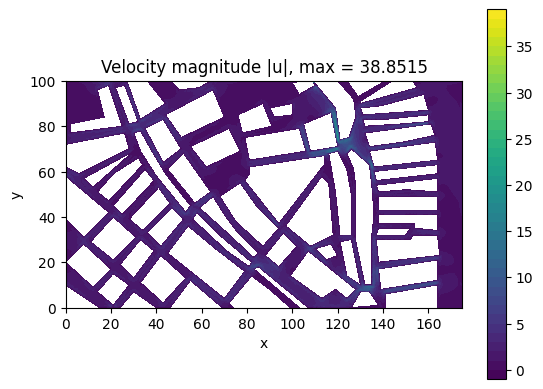

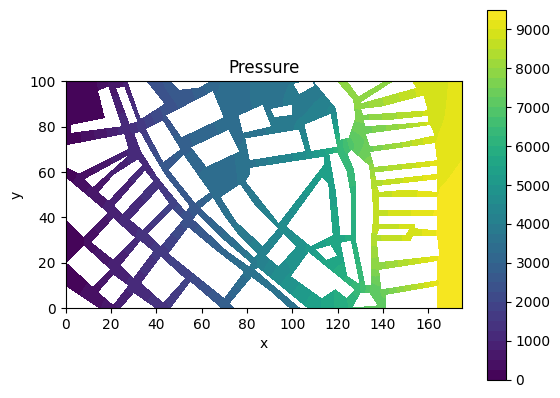

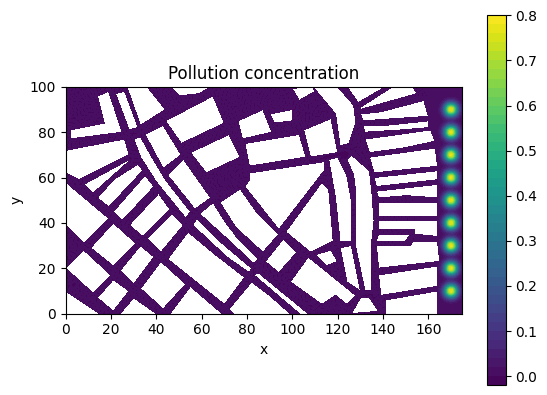

Time t = 3.0059503164164787
Max velocity = 77.94365697423943


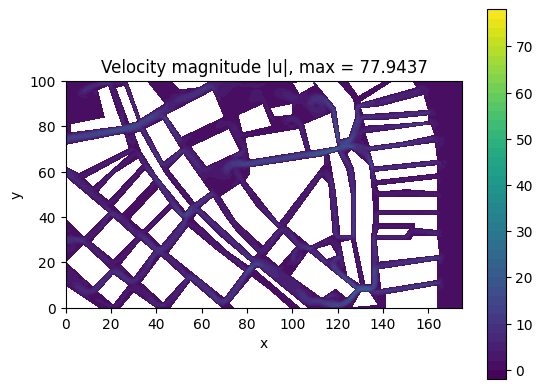

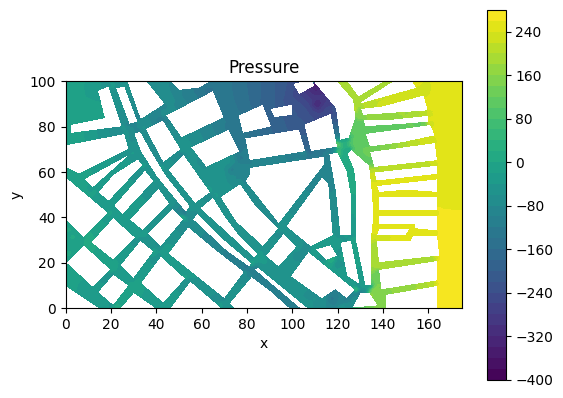

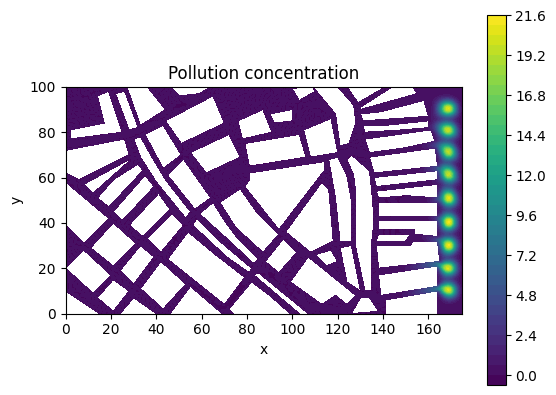

Time t = 6.011900632832951
Max velocity = 96.21261425986337


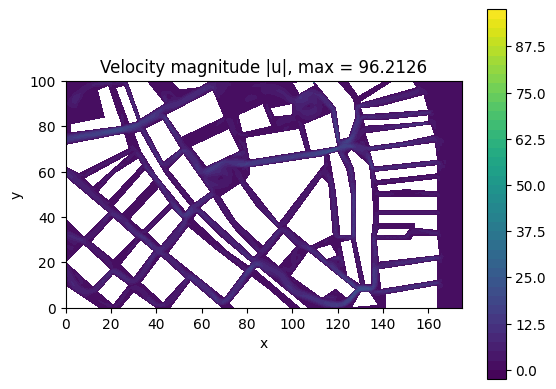

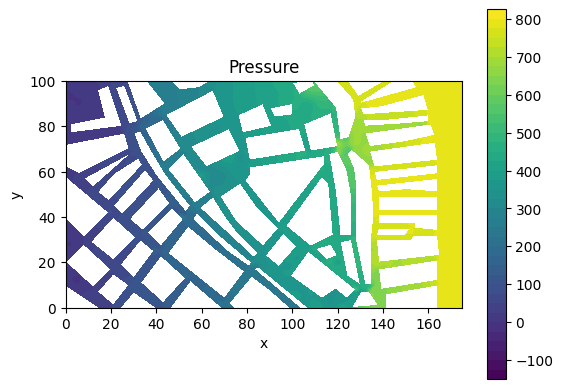

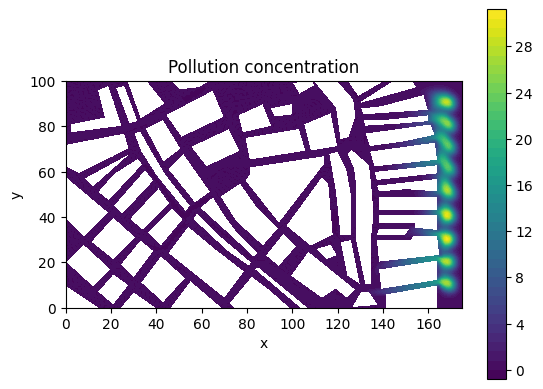

Time t = 9.017850949249418
Max velocity = 78.57307360216704


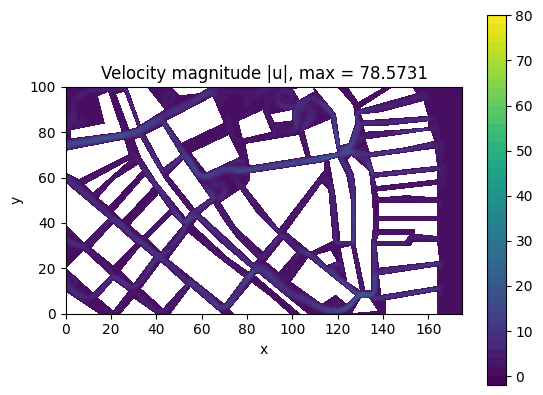

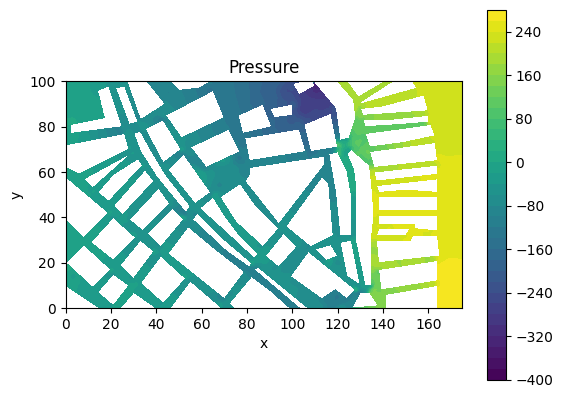

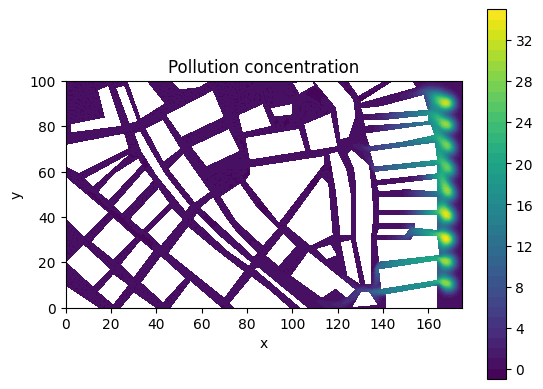

Time t = 12.023801265665885
Max velocity = 95.43960452080314


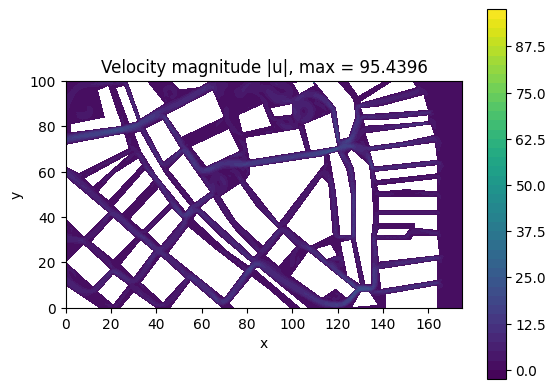

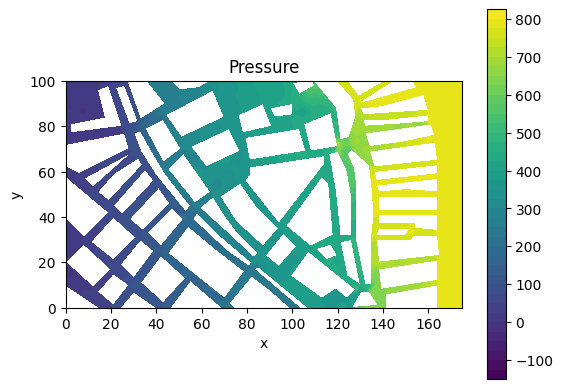

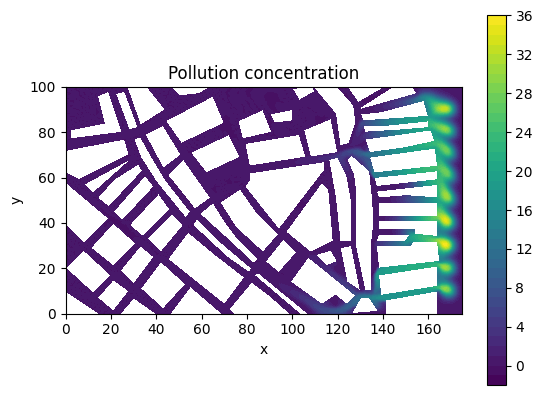

Time t = 15.029751582082351
Max velocity = 78.64264725462556


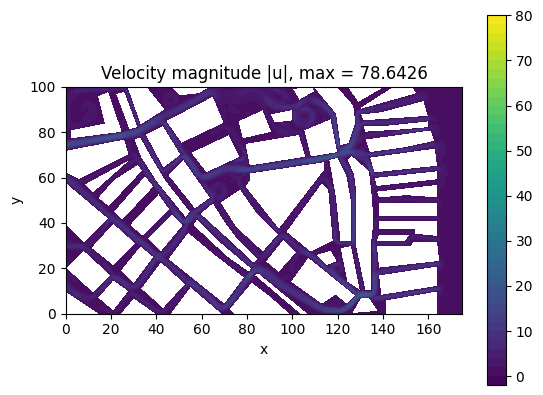

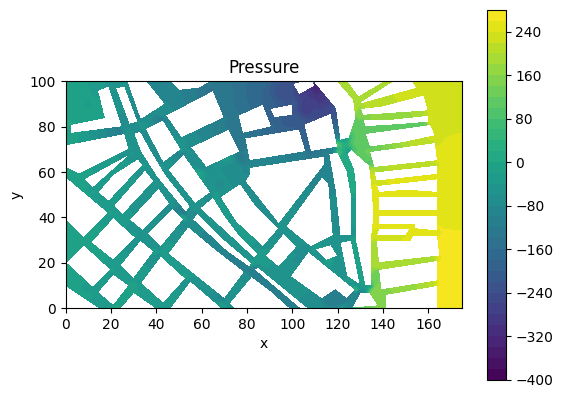

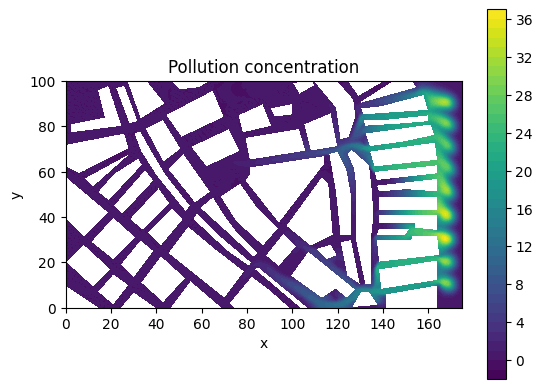

Time t = 18.035701898498818
Max velocity = 95.62062921499928


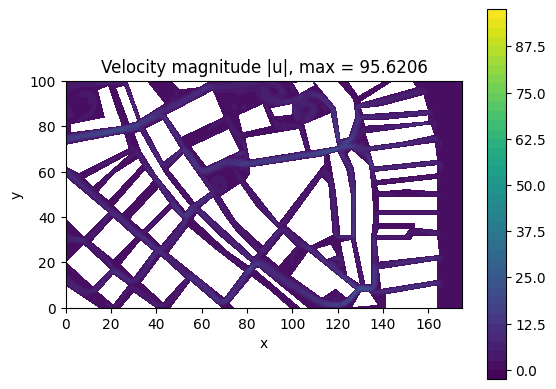

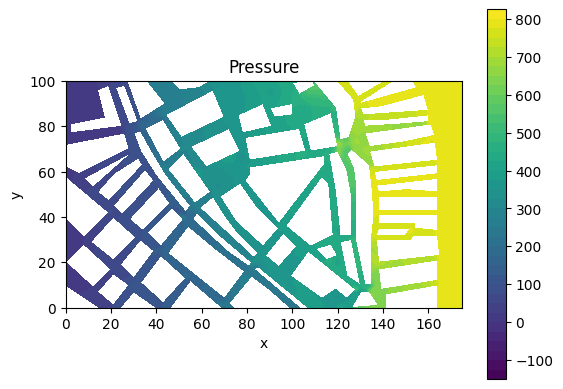

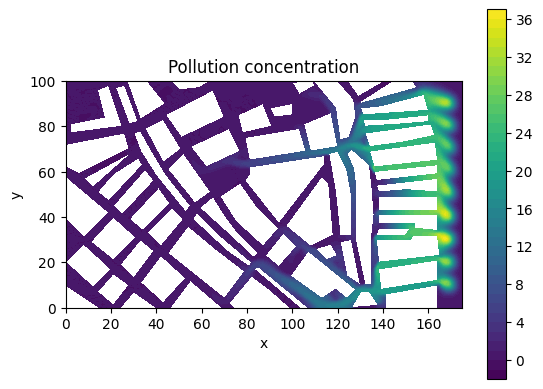

Time t = 21.041652214915285
Max velocity = 78.6797970272895


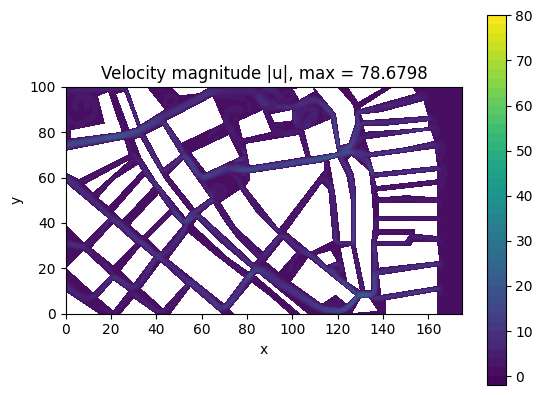

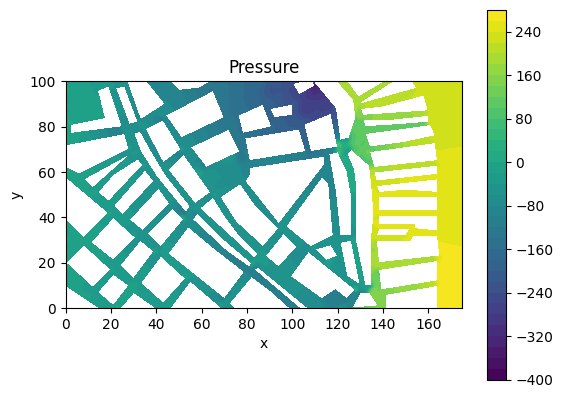

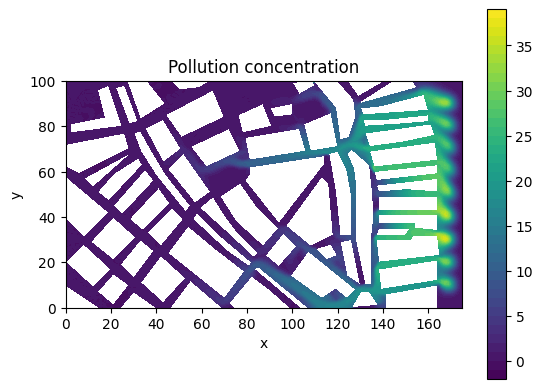

Time t = 24.04760253133175
Max velocity = 95.67177050808947


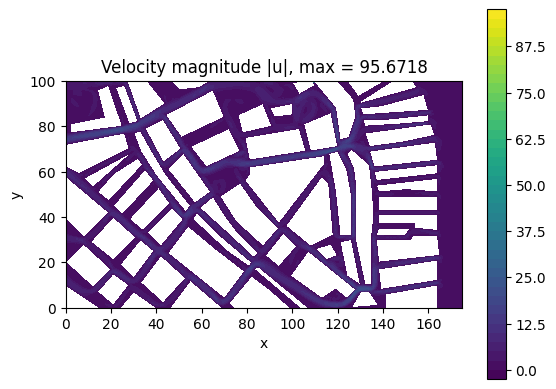

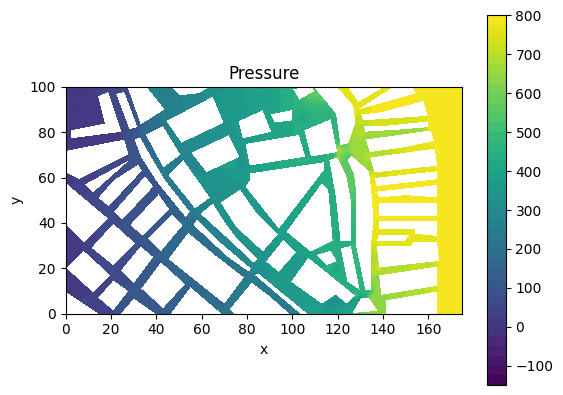

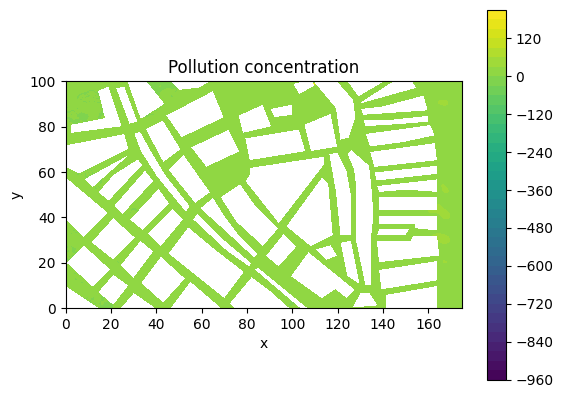

Time t = 27.053552847748218
Max velocity = 78.61849575324788


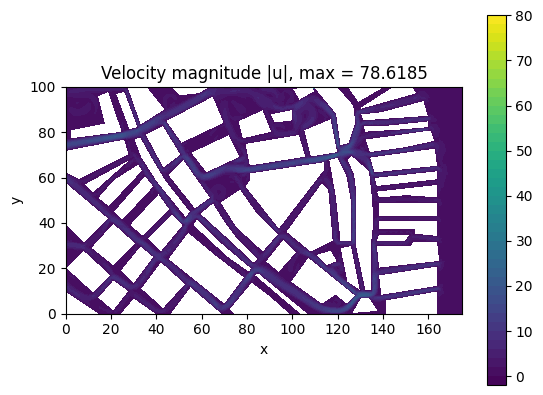

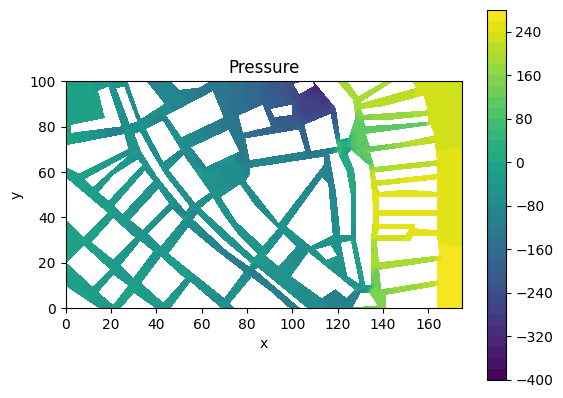

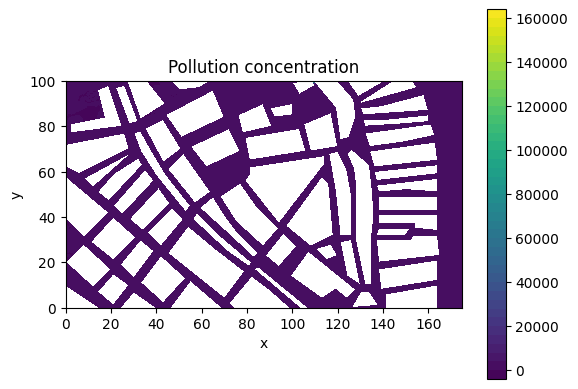

In [54]:
!rm results-NS/*

# Time stepping

# Function space for velocity magnitude
Vmag = FunctionSpace(mesh, "CG", 1)

T = 30
t = dt
while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    pin.t = t
    #uin.t = t

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble momentum matrix and vector
        Au = assemble(au)
        bu = assemble(Lu)

        # Compute velocity solution
        [bc.apply(Au, bu) for bc in bcu]
        [bc.apply(u1.vector()) for bc in bcu]
        solve(Au, u1.vector(), bu, "bicgstab", "default")

        # Assemble continuity matrix and vector
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Compute pressure solution
        [bc.apply(Ap, bp) for bc in bcp]
        [bc.apply(p1.vector()) for bc in bcp]
        solve(Ap, p1.vector(), bp, "bicgstab", prec)

        # Compute force
        #F = assemble(Force)
        #if (t > start_sample_time):
         # force_array = np.append(force_array, normalization*F)
          #time = np.append(time, t)

        k += 1

        # Solve pollution transport equation using the current velocity u1
        Ac = assemble(ac)
        bc_vec = assemble(Lc)

        [bc.apply(Ac, bc_vec) for bc in bc_c]
        solve(Ac, c1.vector(), bc_vec, "bicgstab", "default")

    if t > plot_time:

        s = 'Time t = ' + repr(t)
        print(s)

        # Save solution to file
        file_u << u1
        file_p << p1
        file_c << c1

        # Plot solution
        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plt.figure()
        plot(c1, title="Pollution concentration")

        plot_time += T/plot_freq

        plt.show()




    # Update time step
    u0.assign(u1)
    c0.assign(c1)
    t += dt

#!tar -czvf results-NS.tar.gz results-NS
#files.download('results-NS.tar.gz')

# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Navier-Stokes equations in 2D. The method was tested for the model problem of flow past a circular obstacle, and for a high enough Reynolds number and sufficient mesh resolution [a von Karman vortex street developed as expected.](https://en.wikipedia.org/wiki/Kármán_vortex_street)